In [1]:
import sys
sys.path.append("..")
%run "../moduli.py"

In [2]:
pesata = False

# Lettura

In [3]:
par_labels = [
    r"$Q_{A_{\mathrm{fit}}}$",
    r"$Q_{\Delta \Phi_{\mathrm{fit}}}$",  # da regressione

    r"$Q_{A}$",
    r"$Q_{\Delta \Phi}$",  # fatti da Zoya

    r"$Q_{R_{\mathrm{tot}}, A}$",
    r"$Q$",
    r"$Q_C$"
]

par = [Misura(None, None) for _ in range(len(par_labels))]

Lettura Pickle ampiezza

In [4]:
a = Misura(None, None)
b = Misura(None, None)
c = Misura(None, None)
anal,offset = let.importa_pickle("ampiezza.pkl")
[[a.val, b.val, c.val], [a.s, b.s, c.s]] = anal
[x_off, y_off] = offset
del anal,offset

Q = a.val / (2*c.val)
sQ = Q * np.sqrt( (a.s/a.val)**2 + (c.s/c.val)**2)
par[0] = Misura(Q, sQ)
print(par[0])

9.592445938078912 ± 0.06189577873623326


Lettura Pickle sfasamento

In [5]:
a = Misura(None, None)
b = Misura(None, None)
anal,offset = let.importa_pickle("sfasamento.pkl")
[[a.val, b.val], [a.s, b.s]] = anal
[x_off, y_off] = offset
del anal,offset

par[1] = Misura(abs(b.val), b.s)
print(par[1])

6.464126426280161 ± 0.056278502607281636


Misure di f0 nel Latex

In [6]:
par[2] = Misura(6.8,0.2)
par[3] = Misura(6.69,0.09)
par[4] = Misura(7.5,0.4)
par[5] = Misura(10.5,0.3)
par[6] = Misura(6.9,0.9)

Conversione

In [7]:
valori = np.array([m.val for m in par])
errori = np.array([m.s for m in par])

par = Misura(valori, errori)
del valori,errori

# Analisi

In [8]:
if pesata:
    media = an.media_p(par)
elif not pesata:
    media = an.media(par)

In [9]:
x = list(range(len(par_labels)))

In [10]:
residui = []

for i in range(len(par_labels)):
    res = (media.val - par.val[i])
    residui.append([x[i], res, par.s[i]])

residui = np.array(residui)
res = np.array([residui[:, 0], residui[:, 1], residui[:, 2]])

# Grafico

In [11]:
titolo = "Confronto stime fattore di qualità"

ylabel = "Q"
yunit = "-"

file_output1 = "confronto_Q.pdf"

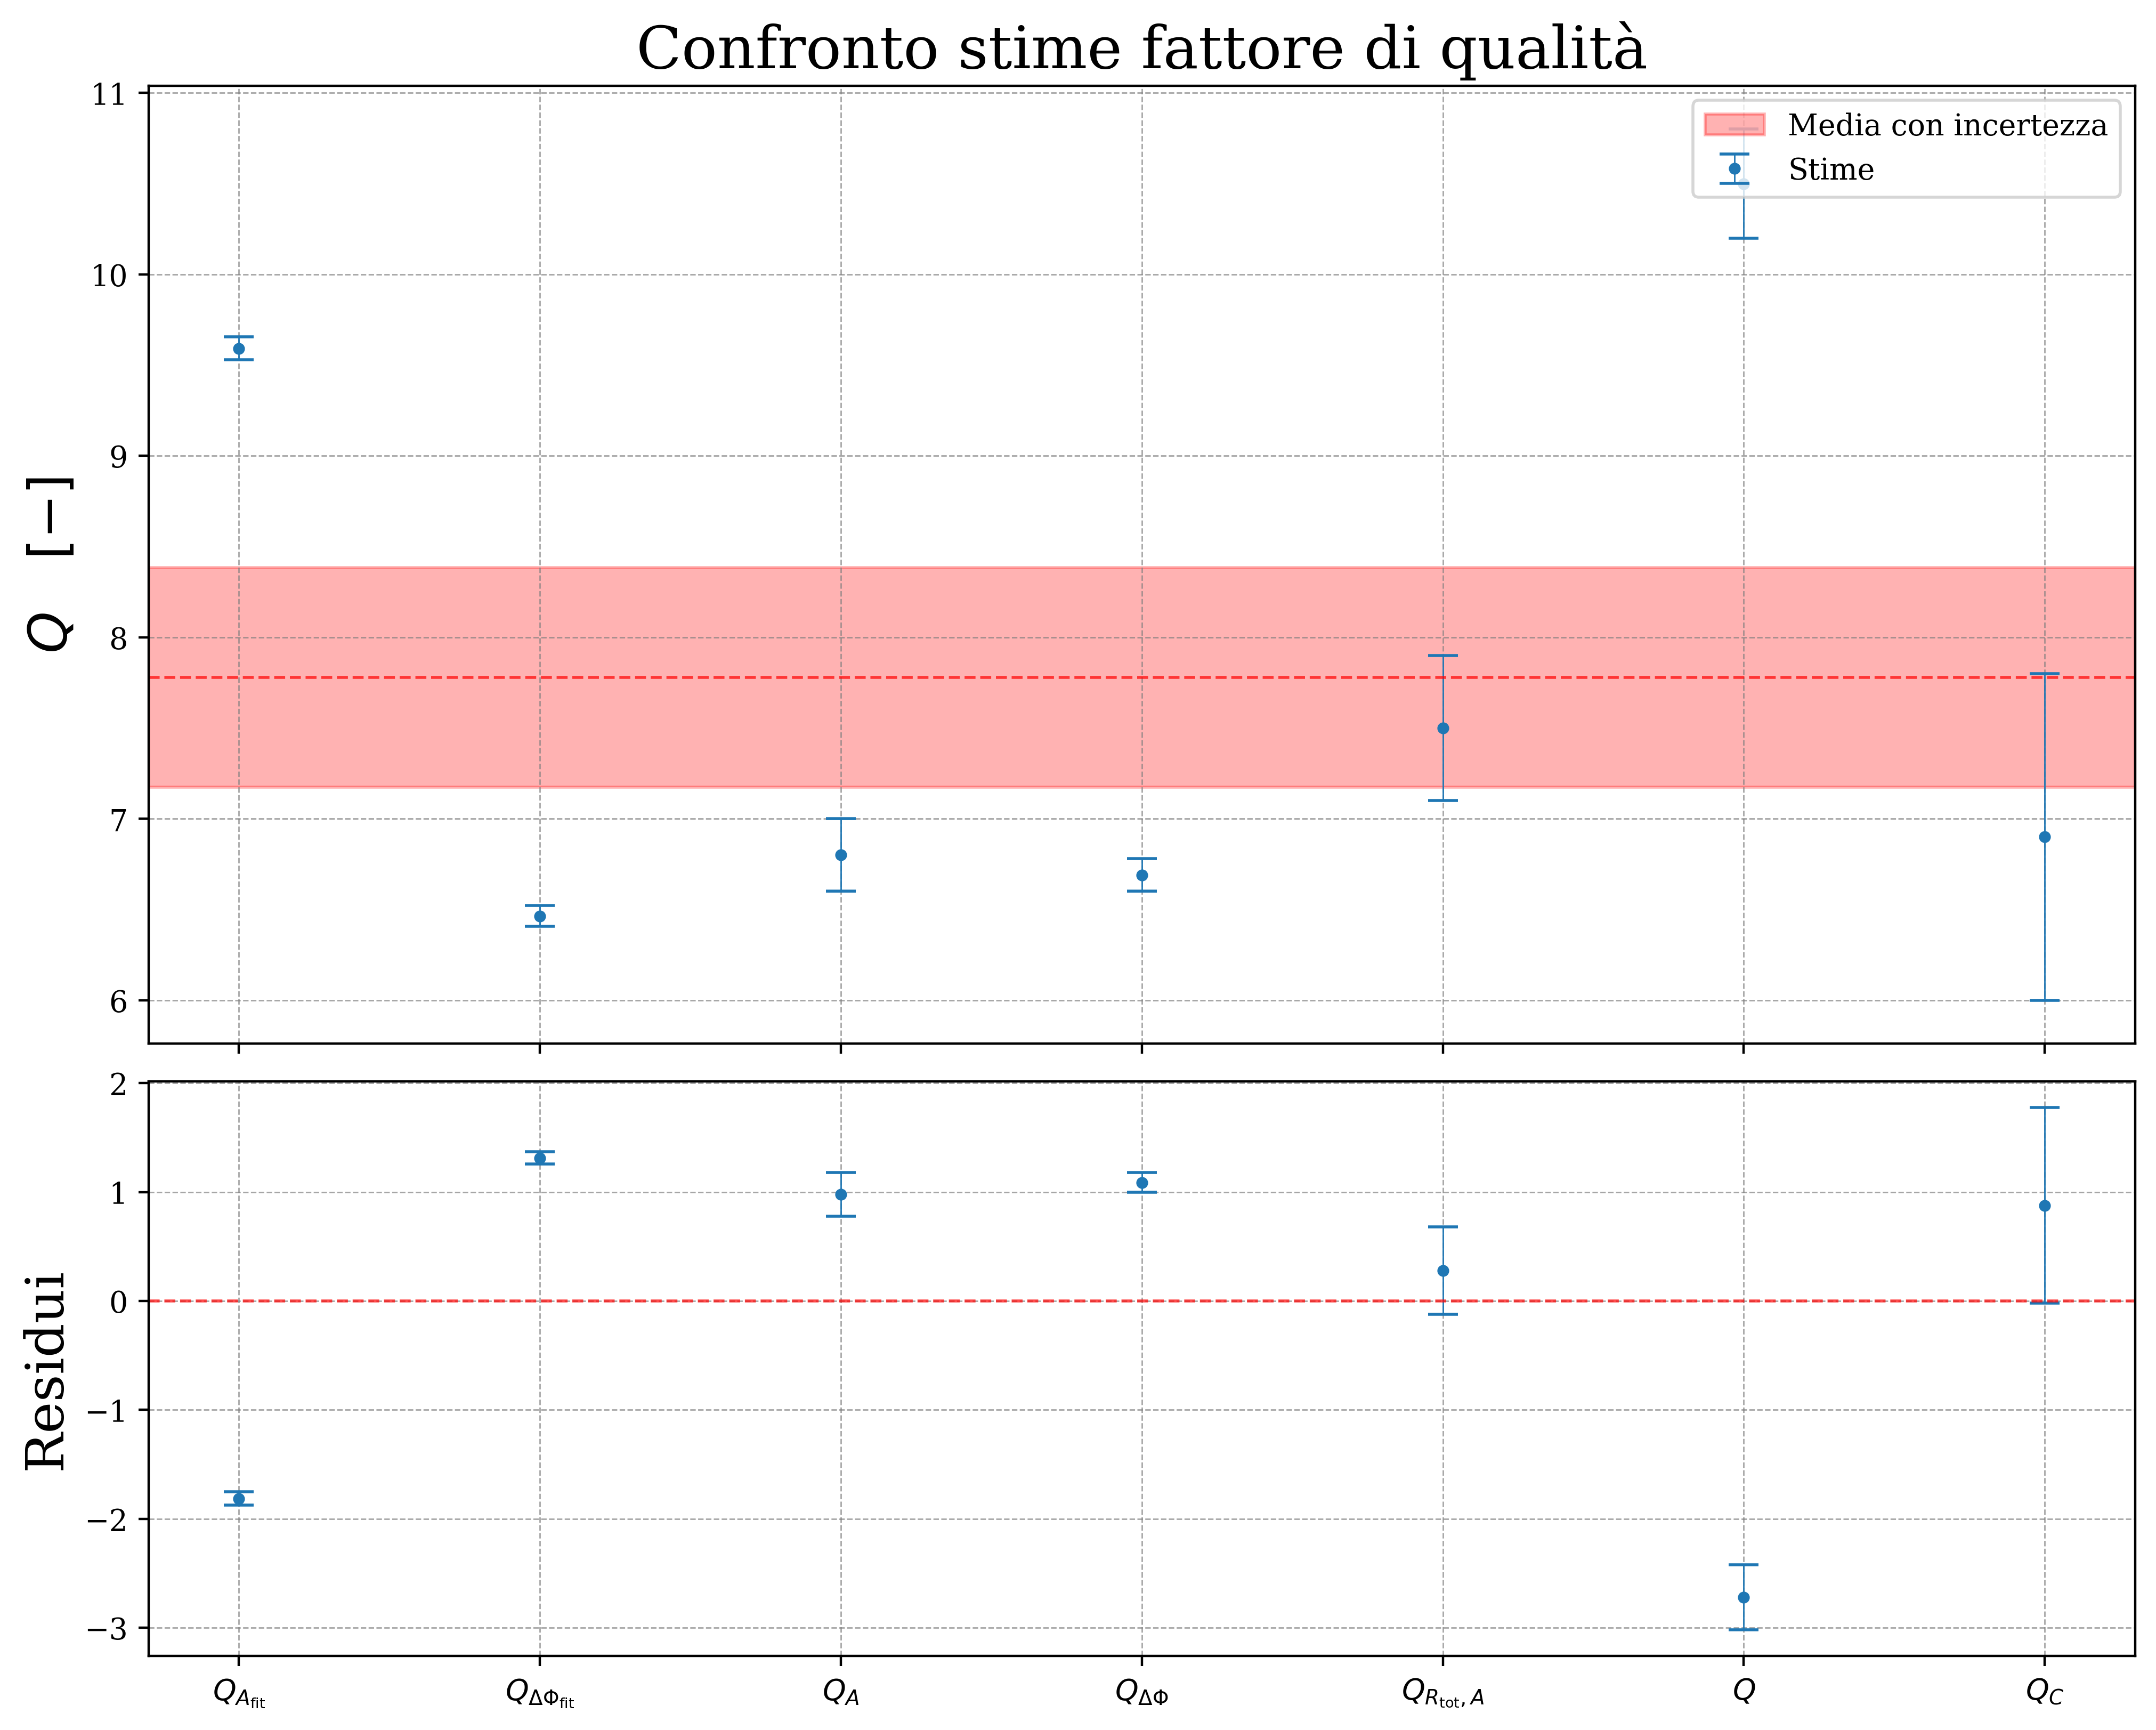

In [12]:
fig1, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(10, 8),
        gridspec_kw={'height_ratios': [5, 3]},
        constrained_layout=True,
        sharex=True
)
ax1.tick_params(axis='x', labelbottom=False)
gf.parametri_grafico(ax1, f"{titolo}", ylabel= rf"${ylabel}\quad [{yunit}]$")
gf.parametri_grafico(ax2, ylabel="Residui")

ax2.set_xticks(range(len(par_labels)))
ax2.set_xticklabels(par_labels)

# Dati
ax1.errorbar(
    x,
    par.val,
    yerr=par.s,
    label="Stime",
    **gf.errorbar_params,
    color = gf.colori[0]
)

# Media
ax1.axhline(
    media.val,
    **gf.line_params,
    color="red"
)
if pesata:
    label = "Media pesata con incertezza"
elif not pesata:
    label = "Media con incertezza"
ax1.axhspan(
    media.val - media.s,
    media.val + media.s,
    alpha=0.3,
    color="red",
    label=label
)

ax1.legend(loc="upper right", bbox_to_anchor=(1,1), fontsize=10)

# Residui
ax2.errorbar(
    res[0],
    res[1],
    yerr=res[2],
    **gf.errorbar_params,
    color=gf.colori[0]
)

# Linea orizzontale
ax2.axhline(
    0,
    **gf.line_params,
    color="red"
)

let.salva_grafico(fig1, file_output1)